In [1]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [41]:
def forest_plot_helper(axs, data_df, model_df, metric):

    # extract data
    data_point = data_df[f"{metric}_point"].values
    model_lbs = model_df[f"{metric}_lb"].values
    model_ubs = model_df[f"{metric}_ub"].values
    model_point = model_df[f"{metric}_point"].values

    # compute fit relative to data
    relative_lbs = model_lbs - data_point
    relative_ubs = model_ubs - data_point
    relative_point = model_point - data_point

    # forest plot
    for r, (lb, pt, ub) in enumerate(zip(relative_lbs, relative_point, relative_ubs)):
        if lb < 0 and ub > 0:
            color = "green"
        else:
            color = "red"
        axs.plot([lb, ub], [r, r], color=color)
        axs.scatter([pt], [r], color=color, s=5)
        axs.axvline(0, color="black", alpha=0.25)

In [42]:
def forest_plot(data_name, model_name, figsize=(24, 4)):

    # load data
    data_df = pd.read_csv(f"./data/{data_name}.csv")
    model_df = pd.read_csv(f"./data/{data_name}-{model_name}.csv", index_col=0)

    # select metrics
    metrics = [
        "mean_1",
        "mean_2",
        "vars_1",
        "vars_2",
        "prsn",
        "sprm"
    ]
    names = [
        "Mean 1",
        "Mean 2",
        "Variance 1",
        "Variance 2",
        "Pearson Correlation",
        "Spearman Correlation"
    ]

    # plot
    fig, axs = plt.subplots(1, 6, figsize=(24, 4))

    for i, metric in enumerate(metrics):
        forest_plot_helper(axs[i], data_df, model_df, metric)
        axs[i].set_title(names[i])

    fig.supxlabel("Statistic relative to observed data")
    fig.suptitle(f"Posterior Predictive Intervals: (data) {data_name}, (model) {model_name}")
    axs[0].set_ylabel("Repeats")
    
    plt.show()

In [50]:
def coverage(data_name, model_name):

    # load data
    data_df = pd.read_csv(f"./data/{data_name}.csv")
    model_df = pd.read_csv(f"./data/{data_name}-{model_name}.csv", index_col=0)

    # select metrics
    metrics = [
        "mean_1",
        "mean_2",
        "vars_1",
        "vars_2",
        "prsn",
        "sprm"
    ]

    # compute coverage
    coverage_dict = {}
    for metric in metrics:
        coverage_dict[metric] = np.mean(
            (model_df[f"{metric}_lb"] <= data_df[f"{metric}_point"]) &
            (model_df[f"{metric}_ub"] >= data_df[f"{metric}_point"])
        )
    coverage_dict['total'] = np.mean(list(coverage_dict.values()))
    coverage_df = pd.DataFrame(coverage_dict, index=[0])
    return coverage_df

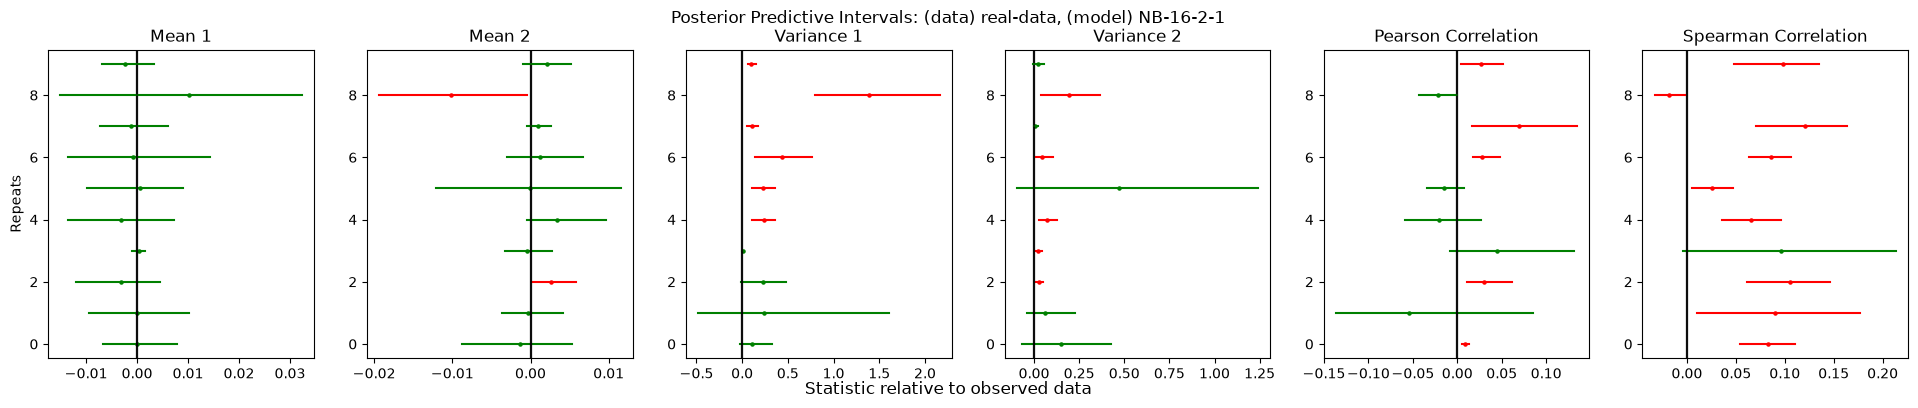

In [43]:
forest_plot("real-data", "NB-16-2-1")

In [49]:
coverage("real-data", "NB-16-2-1")

,mean_1,mean_2,vars_1,vars_2,prsn,sprm,total
0,1.0,0.8,0.4,0.5,0.5,0.1,0.55


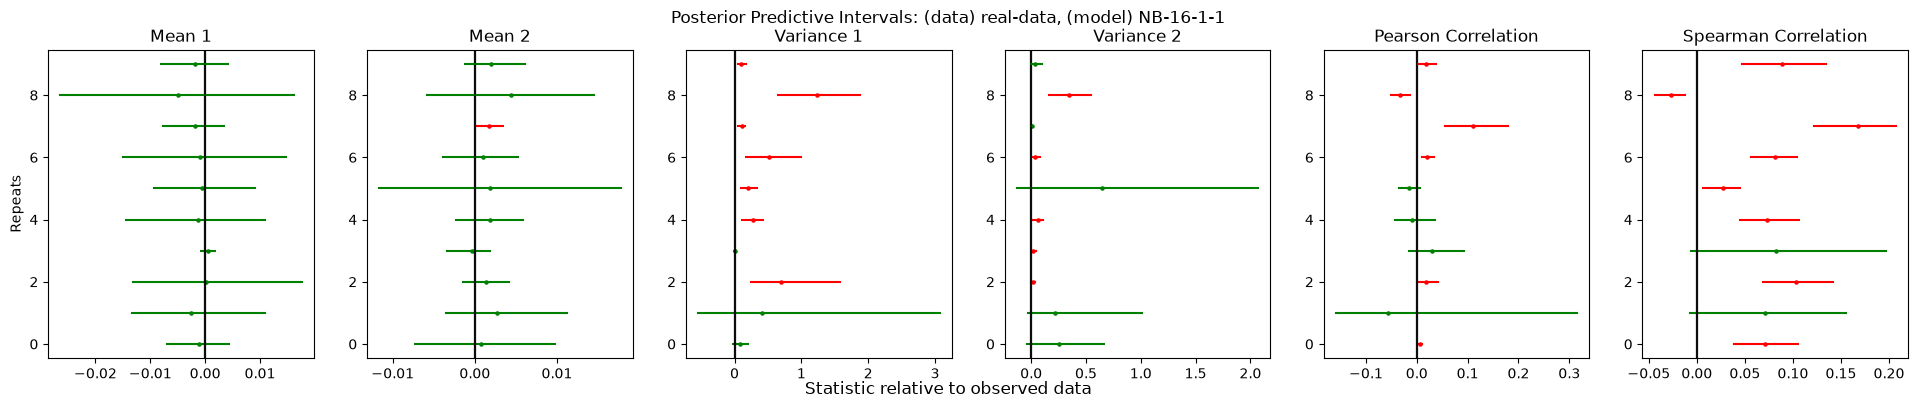

In [51]:
forest_plot("real-data", "NB-16-1-1")

In [52]:
coverage("real-data", "NB-16-1-1")

,mean_1,mean_2,vars_1,vars_2,prsn,sprm,total
0,1.0,0.9,0.3,0.5,0.4,0.2,0.55


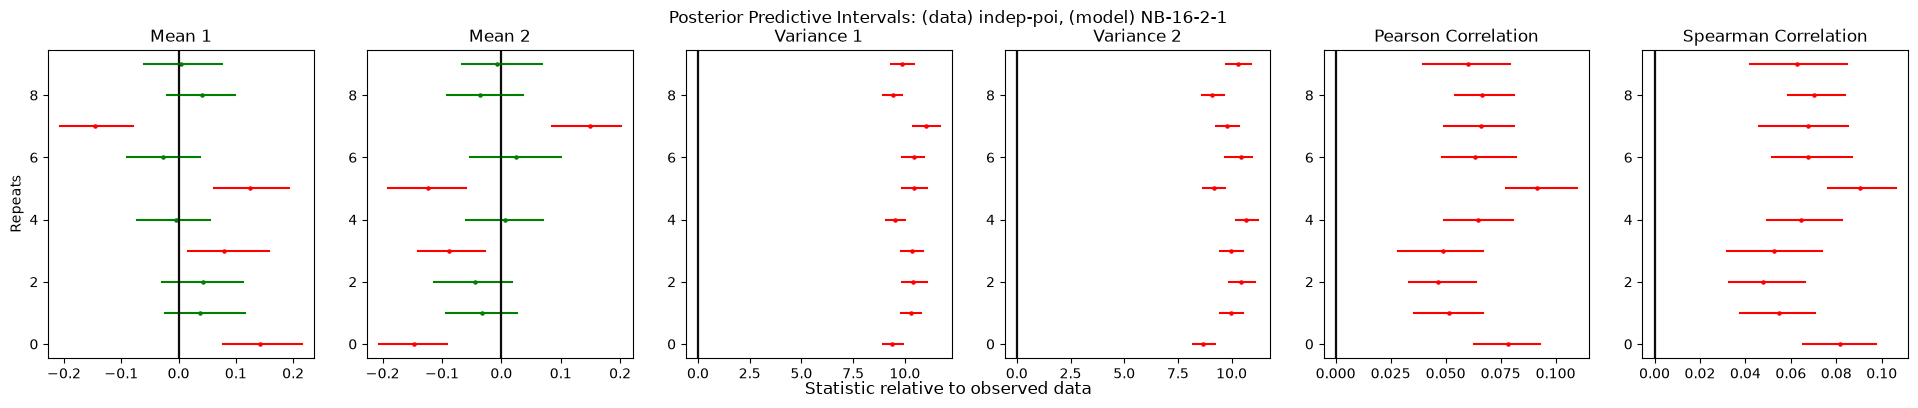

In [54]:
forest_plot("indep-poi", "NB-16-2-1")

In [55]:
coverage("indep-poi", "NB-16-2-1")

,mean_1,mean_2,vars_1,vars_2,prsn,sprm,total
0,0.6,0.6,0.0,0.0,0.0,0.0,0.2


In [57]:
# summary table
data_names = ["indep-poi", "real-data"]
model_names = ["NB-16-1-1", "NB-16-2-1"]

table = pd.DataFrame(columns=["data", "model", "mean_1", "mean_2", "vars_1", "vars_2", "prsn", "sprm", "total"])
for data_name in data_names:
    for model_name in model_names:
        try:
            coverage_df = coverage(data_name, model_name)
        except:
            continue
        coverage_df["data"] = data_name
        coverage_df["model"] = model_name
        table = pd.concat([table, coverage_df], ignore_index=True)

In [59]:
# color table by total coverage
def color_table(val):
    if val < 0.5:
        color = "red"
    elif val < 0.75:
        color = "orange"
    else:
        color = "green"
    return f"color: {color}"

table.style.applymap(color_table, subset=["total"])

AttributeError: 'Styler' object has no attribute 'applymap'

In [71]:
cm = sns.light_palette("green", as_cmap=True)
table.style.background_gradient(cmap=cm, axis=0, subset=["mean_1", "mean_2", "vars_1", "vars_2", "prsn", "sprm", "total"])

,data,model,mean_1,mean_2,vars_1,vars_2,prsn,sprm,total
0,indep-poi,NB-16-2-1,0.600000,0.600000,0.000000,0.000000,0.000000,0.000000,0.200000
1,real-data,NB-16-1-1,1.000000,0.900000,0.300000,0.500000,0.400000,0.200000,0.550000
2,real-data,NB-16-2-1,1.000000,0.800000,0.400000,0.500000,0.500000,0.100000,0.550000
